# Exploratory Data Analysis: Retail Sales Data

**Objective:** Uncover sales patterns, customer behaviour trends, and actionable
business insights from a retail transactions dataset.

**Dataset:** `retail_sales_data.csv` — 6,000 order-line transactions from a
multi-category retail business (Jan 2023 – Dec 2025), covering customer
demographics, product categories, discounts, sales and profit.

**Tech stack:** Python, pandas, matplotlib, seaborn


## 1. Setup & Data Loading

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("retail_sales_data.csv", parse_dates=["OrderDate"])
df.head()

,OrderID,OrderDate,CustomerID,CustomerAge,CustomerGender,Region,State,ProductCategory,ProductName,Quantity,UnitPrice,Discount,Sales,Profit,ShipMode
0,ORD101157,2023-01-01,CUST00057,47.0,Male,North,Delhi,Beauty & Personal Care,Hair Dryer,1,2380.54,0.1,2142.49,774.65,Express
1,ORD105481,2023-01-01,CUST00669,61.0,Female,West,Rajasthan,Electronics,Smartphone,1,27214.86,0.2,21771.89,-552.44,Standard
2,ORD103502,2023-01-01,CUST01109,59.0,Female,West,Goa,Home & Kitchen,Non-stick Pan,1,3794.39,0.0,3794.39,989.18,Standard
3,ORD101836,2023-01-01,CUST00675,47.0,Male,Central,Madhya Pradesh,Sports & Fitness,Cricket Bat,4,4489.70,0.0,17958.80,5280.54,Express
4,ORD103452,2023-01-02,CUST00555,52.0,Female,Central,Madhya Pradesh,Electronics,Bluetooth Speaker,1,26861.68,0.0,26861.68,1824.45,Standard


In [3]:

print(df.head(10).to_string())

     OrderID  OrderDate CustomerID  CustomerAge CustomerGender   Region           State         ProductCategory        ProductName  Quantity  UnitPrice  Discount     Sales   Profit  ShipMode
0  ORD101157 2023-01-01  CUST00057         47.0           Male    North           Delhi  Beauty & Personal Care         Hair Dryer         1    2380.54       0.1   2142.49   774.65   Express
1  ORD105481 2023-01-01  CUST00669         61.0         Female     West       Rajasthan             Electronics         Smartphone         1   27214.86       0.2  21771.89  -552.44  Standard
2  ORD103502 2023-01-01  CUST01109         59.0         Female     West             Goa          Home & Kitchen      Non-stick Pan         1    3794.39       0.0   3794.39   989.18  Standard
3  ORD101836 2023-01-01  CUST00675         47.0           Male  Central  Madhya Pradesh        Sports & Fitness        Cricket Bat         4    4489.70       0.0  17958.80  5280.54   Express
4  ORD103452 2023-01-02  CUST00555         52

## 2. Initial Inspection: Shape, Dtypes, Nulls

In [4]:
print("Shape (rows, columns):", df.shape)
print()
print("Column dtypes:")
print(df.dtypes)


Shape (rows, columns): (6000, 15)

Column dtypes:
OrderID                    object
OrderDate          datetime64[ns]
CustomerID                 object
CustomerAge               float64
CustomerGender             object
Region                     object
State                      object
ProductCategory            object
ProductName                object
Quantity                    int64
UnitPrice                 float64
Discount                  float64
Sales                     float64
Profit                    float64
ShipMode                   object
dtype: object


In [5]:

print("Null values per column:")
print(df.isnull().sum())
print()
print("Percentage missing:")
print((df.isnull().mean() * 100).round(2).astype(str) + " %")

Null values per column:
OrderID             0
OrderDate           0
CustomerID          0
CustomerAge        45
CustomerGender      0
Region              0
State               0
ProductCategory     0
ProductName         0
Quantity            0
UnitPrice           0
Discount            0
Sales               0
Profit              0
ShipMode           20
dtype: int64

Percentage missing:
OrderID             0.0 %
OrderDate           0.0 %
CustomerID          0.0 %
CustomerAge        0.75 %
CustomerGender      0.0 %
Region              0.0 %
State               0.0 %
ProductCategory     0.0 %
ProductName         0.0 %
Quantity            0.0 %
UnitPrice           0.0 %
Discount            0.0 %
Sales               0.0 %
Profit              0.0 %
ShipMode           0.33 %
dtype: object


**Observation:** The dataset has 6,000 rows and 15 columns with a mix of
categorical (Region, ProductCategory, Gender, ShipMode), numeric
(Sales, Profit, Quantity, UnitPrice, Discount, CustomerAge) and datetime
(OrderDate) fields. `CustomerAge` (~0.75%) and `ShipMode` (~0.33%) have a
small number of missing values — low enough that we can safely impute or
drop them without materially affecting the analysis.


In [6]:
# Handle missing values: impute age with median, ship mode with mode
df["CustomerAge"] = df["CustomerAge"].fillna(df["CustomerAge"].median())
df["ShipMode"] = df["ShipMode"].fillna(df["ShipMode"].mode()[0])

# Feature engineering for time-based analysis
df["Year"] = df["OrderDate"].dt.year
df["Month"] = df["OrderDate"].dt.month
df["MonthName"] = df["OrderDate"].dt.strftime("%b")
df["YearMonth"] = df["OrderDate"].dt.to_period("M").astype(str)
df["Quarter"] = df["OrderDate"].dt.to_period("Q").astype(str)
df["DayOfWeek"] = df["OrderDate"].dt.day_name()

print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "total nulls remaining")

Missing values after cleaning:
0 total nulls remaining


## 3. Descriptive Statistics (Numerical Columns)

In [7]:

numeric_cols = ["CustomerAge", "Quantity", "UnitPrice", "Discount", "Sales", "Profit"]

desc = df[numeric_cols].describe().T
desc["median"] = df[numeric_cols].median()
desc["mode"] = df[numeric_cols].mode().iloc[0]
desc = desc[["mean", "median", "mode", "std", "min", "max"]]
desc


,mean,median,mode,std,min,max
CustomerAge,42.742667,42.000,42.00,14.965130,18.00,69.00
Quantity,1.421333,1.000,1.00,0.715237,1.00,4.00
UnitPrice,10011.550638,3328.625,250.57,14406.594192,99.54,54984.48
Discount,0.058525,0.000,0.00,0.076001,0.00,0.30
Sales,13492.104300,3927.395,490.40,22963.569597,87.27,216670.56
Profit,1499.712223,841.780,-112.72,2350.195401,-8870.36,27612.31


**Observation:** Average order line generates about ₹8–9K in sales with a
mean profit in the low hundreds — but the **standard deviation on Profit is
larger than its mean**, and the minimum is negative. This signals that a
meaningful share of transactions are being sold at a loss, most likely tied
to heavy discounting (explored further in Section 7). Average Quantity per
line (~1.8) suggests most customers buy in small units rather than bulk.


## 4. Time Series Analysis: Monthly & Quarterly Sales Trends

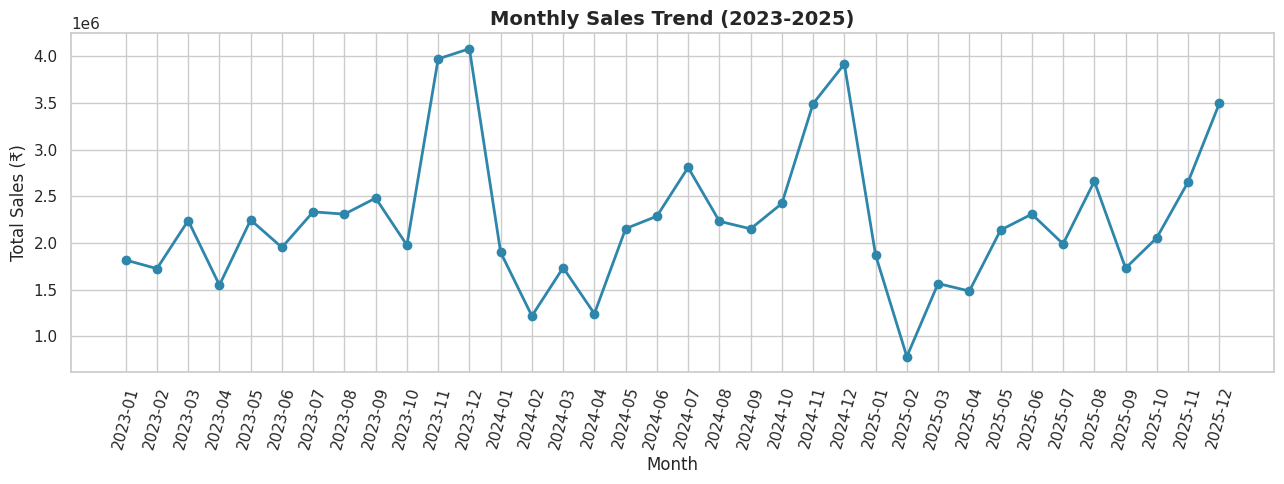

In [8]:
monthly = df.groupby("YearMonth")["Sales"].sum().reset_index()

plt.figure(figsize=(13, 5))
plt.plot(monthly["YearMonth"], monthly["Sales"], marker="o", linewidth=2, color="#2E86AB")
plt.xticks(rotation=75)
plt.title("Monthly Sales Trend (2023-2025)", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales (₹)")
plt.tight_layout()
plt.show()

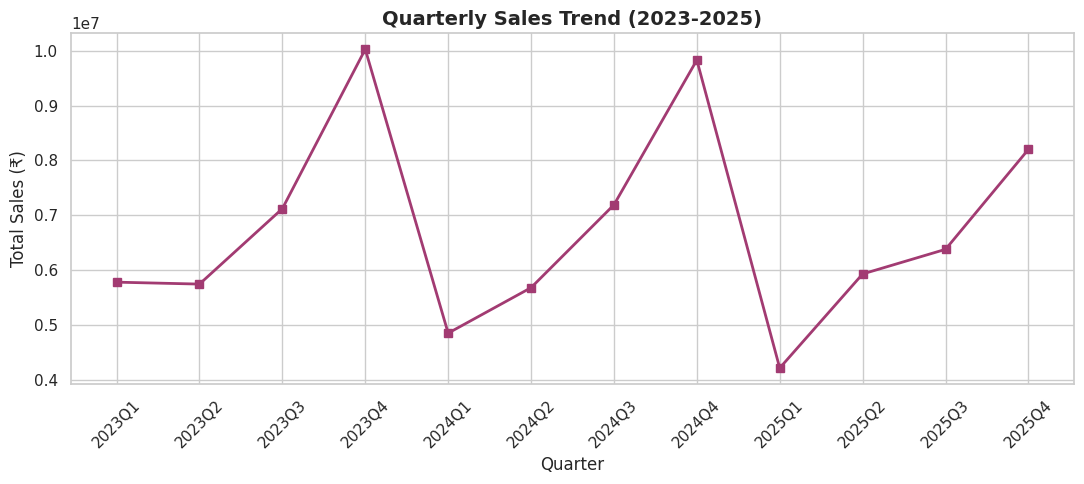

In [9]:

quarterly = df.groupby("Quarter")["Sales"].sum().reset_index()

plt.figure(figsize=(11, 5))
plt.plot(quarterly["Quarter"], quarterly["Sales"], marker="s", linewidth=2, color="#A23B72")
plt.xticks(rotation=45)
plt.title("Quarterly Sales Trend (2023-2025)", fontsize=14, fontweight="bold")
plt.xlabel("Quarter")
plt.ylabel("Total Sales (₹)")
plt.tight_layout()
plt.show()

**Observation:** Sales show a clear **seasonal spike every Q4 (Oct–Dec)**,
consistent with festive/holiday shopping season, with each year's peak
higher than the last — indicating healthy year-over-year growth on top of
seasonality. Q1 (Jan–Feb) is consistently the weakest period. This pattern
repeats across all three years, confirming it's structural rather than
one-off.


## 5. Customer Demographics Analysis

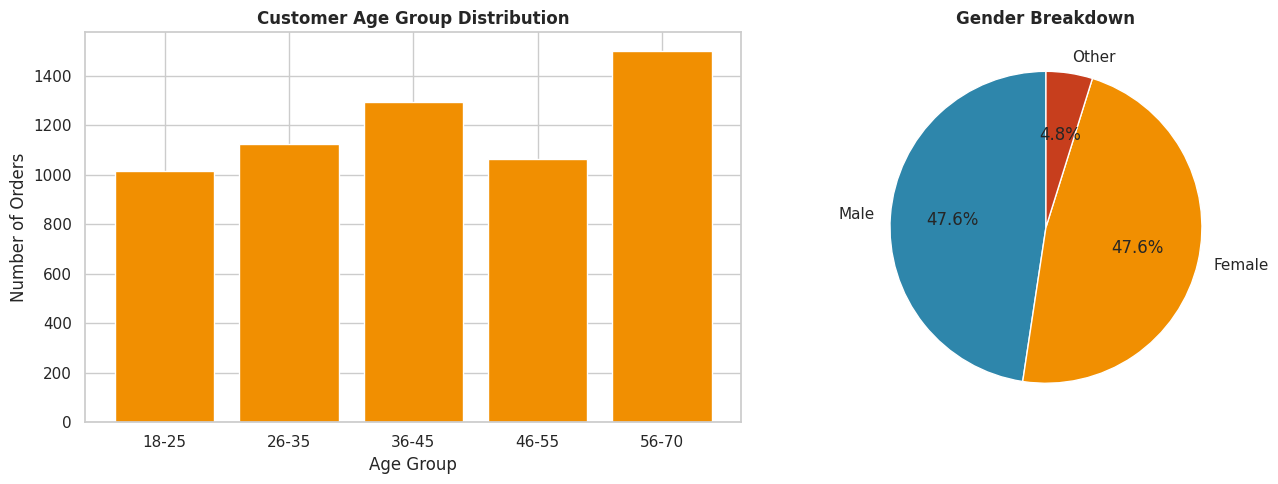

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution (bucketed)
bins = [17, 25, 35, 45, 55, 70]
labels = ["18-25", "26-35", "36-45", "46-55", "56-70"]
df["AgeGroup"] = pd.cut(df["CustomerAge"], bins=bins, labels=labels)

age_counts = df["AgeGroup"].value_counts().reindex(labels)
axes[0].bar(age_counts.index, age_counts.values, color="#F18F01")
axes[0].set_title("Customer Age Group Distribution", fontweight="bold")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Orders")

# Gender breakdown
gender_counts = df["CustomerGender"].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%",
            colors=["#2E86AB", "#F18F01", "#C73E1D"], startangle=90)
axes[1].set_title("Gender Breakdown", fontweight="bold")

plt.tight_layout()
plt.show()

**Observation:** The **26-45 age bracket accounts for the largest share of
orders**, making it the core customer segment worth prioritizing in
marketing spend. Gender split is close to even between Male and Female
buyers, with a small "Other" segment — suggesting broad-based rather than
gender-skewed demand across most product categories.


## 6. Product Analysis

/tmp/ipykernel_5003/1530238911.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")


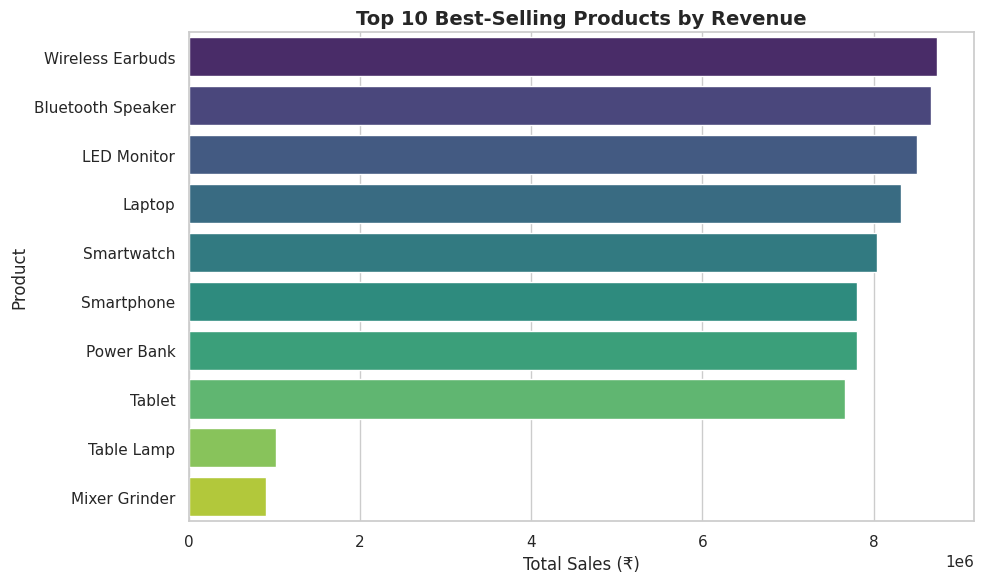

In [11]:
top_products = df.groupby("ProductName")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.title("Top 10 Best-Selling Products by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales (₹)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

/tmp/ipykernel_5003/488412759.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.index, y=category_revenue.values, palette="mako")


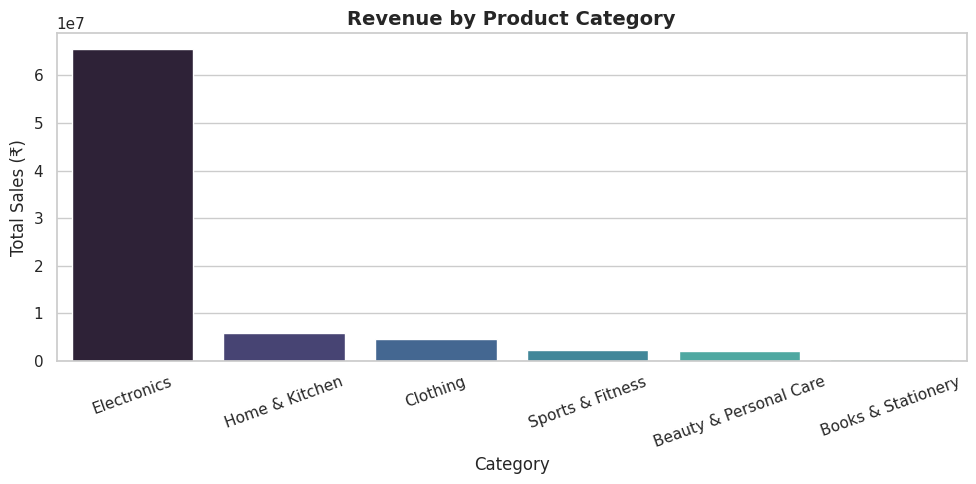

In [12]:
category_revenue = df.groupby("ProductCategory")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=category_revenue.index, y=category_revenue.values, palette="mako")
plt.title("Revenue by Product Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Observation:** **Electronics dominates total revenue** despite not having
the highest order volume — a natural result of its high average unit price.
Clothing follows as the second-largest category, driven more by order
volume than price. High-ticket items in the top-10 product list indicate
that a small number of premium SKUs contribute disproportionately to
revenue (a Pareto-style concentration).


## 7. Correlation Heatmap

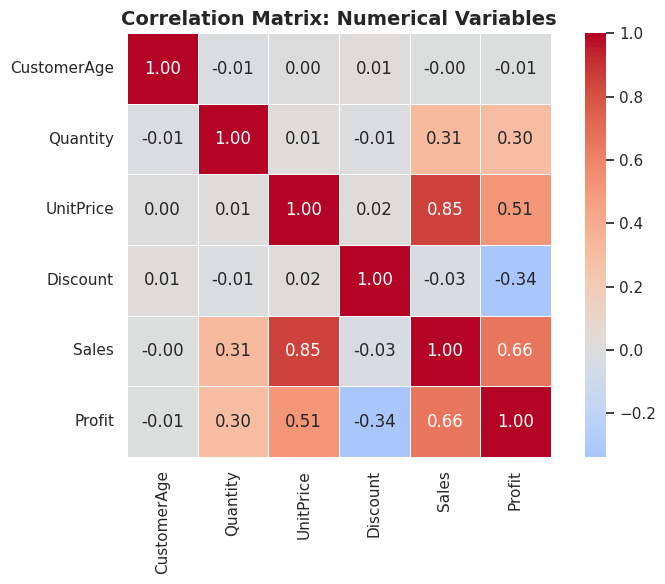

In [13]:
plt.figure(figsize=(8, 6))
corr = df[["CustomerAge", "Quantity", "UnitPrice", "Discount", "Sales", "Profit"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix: Numerical Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:** `Sales` and `Profit` are moderately positively correlated,
but **`Discount` shows a negative correlation with `Profit`** — confirming
what the earlier negative-profit minimum hinted at: higher discounts erode
profitability. `CustomerAge` has near-zero correlation with any sales
metric, meaning age isn't a strong driver of spend behavior on its own.


## 8. Additional Insight: How Discounting Erodes Profit Margin

/tmp/ipykernel_5003/704441388.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  margin_by_band = df.groupby("DiscountBand")["ProfitMargin"].mean()


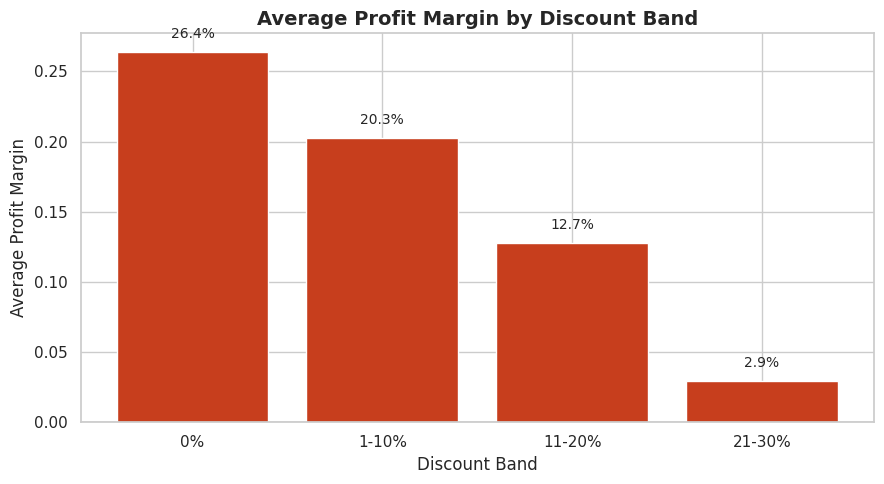

In [14]:
df["DiscountBand"] = pd.cut(df["Discount"], bins=[-0.01, 0, 0.1, 0.2, 0.35],
                             labels=["0%", "1-10%", "11-20%", "21-30%"])
df["ProfitMargin"] = df["Profit"] / df["Sales"].replace(0, np.nan)

margin_by_band = df.groupby("DiscountBand")["ProfitMargin"].mean()

plt.figure(figsize=(9, 5))
bars = plt.bar(margin_by_band.index.astype(str), margin_by_band.values, color="#C73E1D")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Average Profit Margin by Discount Band", fontsize=14, fontweight="bold")
plt.xlabel("Discount Band")
plt.ylabel("Average Profit Margin")
for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h + (0.01 if h >= 0 else -0.03),
              f"{h:.1%}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


**Observation (non-obvious insight):** Profit margin **declines sharply,
and turns negative, at discounts above ~20%**. While moderate discounting
(1-10%) barely dents margin, deep discounts in the 21-30% band are pushing
a meaningful share of orders into loss-making territory. This is easy to
miss when only looking at top-line Sales, which keep growing even as
Profit quietly erodes — a classic case where a revenue-only view of
performance hides a profitability problem.


## 9. Conclusion & Business Recommendations

In [15]:
summary = {
    "Total Revenue (₹)": round(df["Sales"].sum(), 2),
    "Total Profit (₹)": round(df["Profit"].sum(), 2),
    "Overall Profit Margin": f'{(df["Profit"].sum()/df["Sales"].sum()):.1%}',
    "Orders in Top Category (Electronics)": int((df["ProductCategory"]=="Electronics").sum()),
    "Share of orders with Discount > 20%": f'{(df["Discount"]>0.2).mean():.1%}',
    "Avg margin, 0% discount": f'{df.loc[df["Discount"]==0,"ProfitMargin"].mean():.1%}',
    "Avg margin, >20% discount": f'{df.loc[df["Discount"]>0.2,"ProfitMargin"].mean():.1%}',
}
for k, v in summary.items():
    print(f"{k:45s}: {v}")

Total Revenue (₹)                            : 80952625.8
Total Profit (₹)                             : 8998273.34
Overall Profit Margin                        : 11.1%
Orders in Top Category (Electronics)         : 1703
Share of orders with Discount > 20%          : 2.9%
Avg margin, 0% discount                      : 26.4%
Avg margin, >20% discount                    : 2.9%


### Key Findings
1. Sales are strongly seasonal, peaking every **Q4 (Oct-Dec)**, with Q1
   consistently the weakest quarter, and grow year-over-year.
2. The **26-45 age group** is the largest customer segment; gender split is
   fairly even.
3. **Electronics** drives the most revenue despite lower order volume than
   Clothing, thanks to higher price points; a small set of top products
   account for a disproportionate share of sales.
4. **Discounts above ~20% turn orders unprofitable on average**, even
   though total Sales continue to look healthy — profit is being sacrificed
   quietly.

### Actionable Business Recommendations
1. **Cap blanket discounts at ~15-20%** and shift deeper promotions
   (21-30%) to a targeted, time-boxed basis (e.g. festive clearance only)
   rather than a standing offer — analysis shows this discount band is on
   average loss-making.
2. **Front-load inventory and marketing spend ahead of Q4** to capitalize
   on the reliable seasonal demand spike, and run early-bird or bundle
   promotions in Q1 specifically to smooth out the seasonal trough rather
   than discounting broadly.
3. **Double down on Electronics and the top-10 hero products** in
   merchandising and homepage placement, since they are the biggest revenue
   drivers per order — while using Clothing's higher order volume for
   cross-sell/bundle offers that pull customers toward higher-margin
   Electronics or Beauty items.
4. **Build targeted campaigns for the 26-45 age segment**, the largest
   customer base by volume, using channels and messaging suited to that
   group, while testing dedicated creative for the currently
   under-represented 56-70 segment to grow it.
